In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

#import dataset


In [117]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [118]:
df["class"] = (df["class"] == "g").astype(int)

In [119]:
df.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


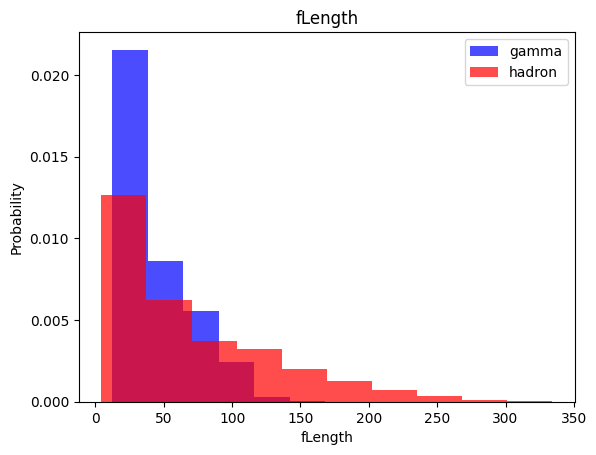

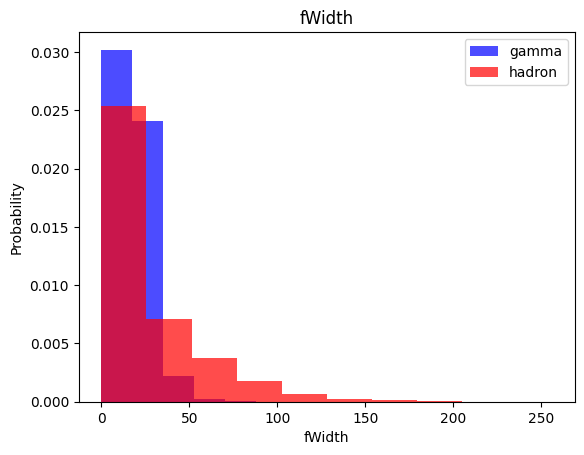

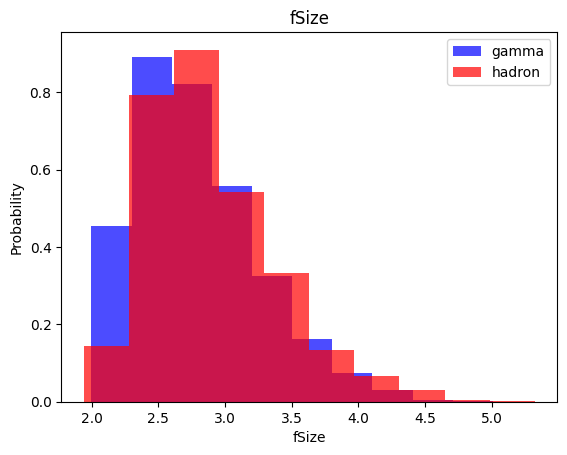

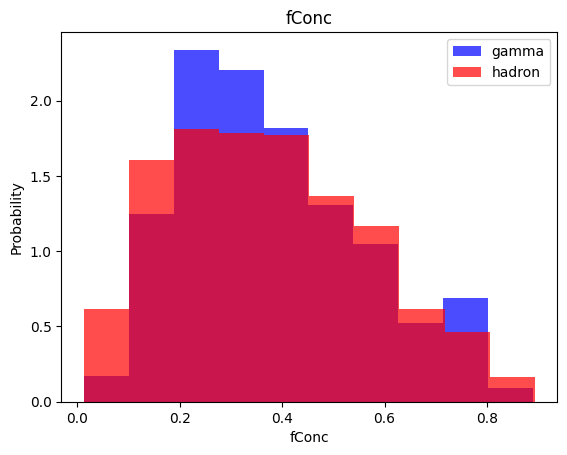

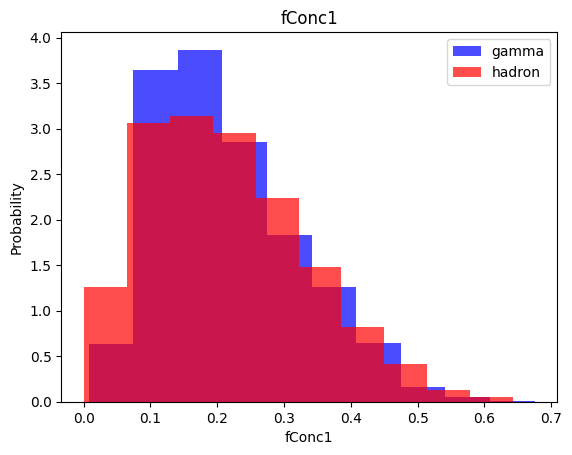

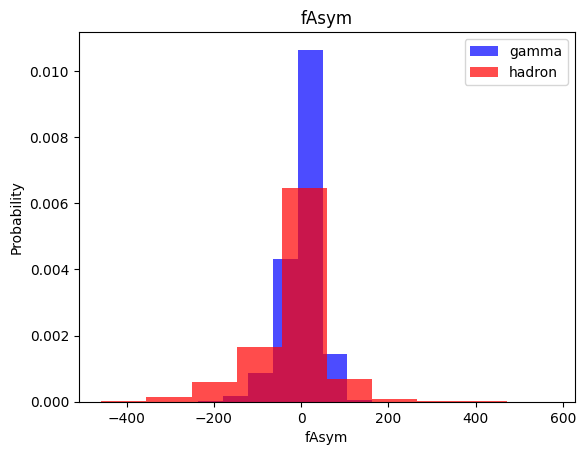

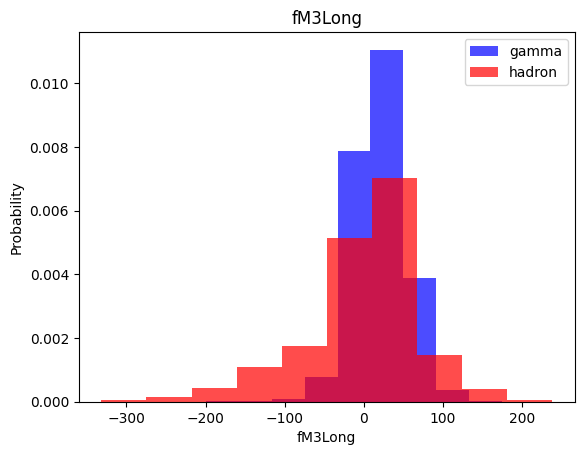

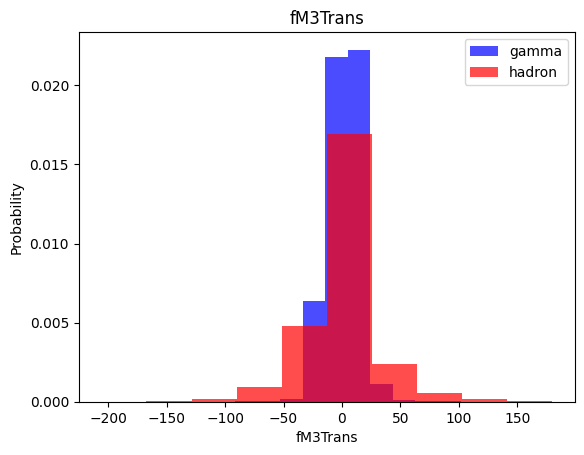

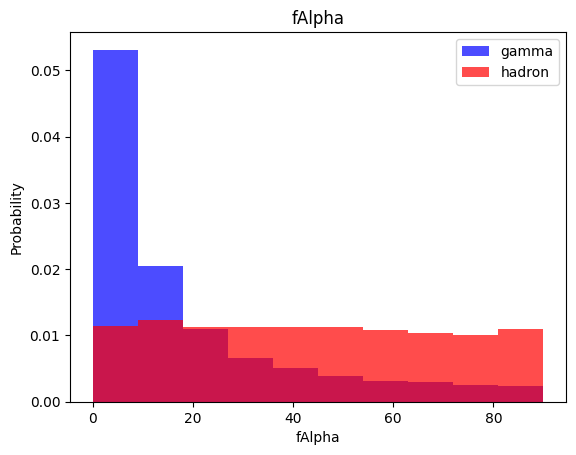

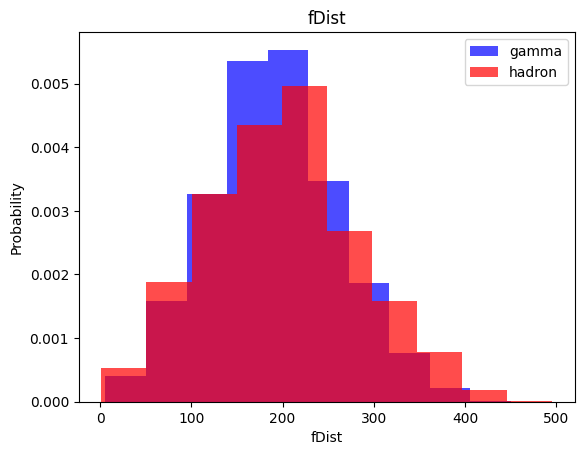

In [120]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color = 'blue', label = 'gamma', alpha = 0.7, density = True)
  plt.hist(df[df["class"]==0][label], color = 'red', label = 'hadron', alpha = 0.7, density = True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

#Train, validation, test dataset


In [121]:
train, valid, test = np.split(df.sample(frac=1),  [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [122]:
def scale_dataset(dataframe, oversample = False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1,1))))
  return data, x, y




In [123]:
train , x_train, y_train = scale_dataset(train, oversample=True)
valid , x_valid, y_valid = scale_dataset(valid, oversample=False)
test , x_test, y_test = scale_dataset(test, oversample=False)

# kNN algorithm


In [124]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [125]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

In [126]:
y_pred = knn_model.predict(x_test)

In [127]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1320
           1       0.86      0.86      0.86      2484

    accuracy                           0.81      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.81      0.81      0.81      3804



#Naive Bayes

In [128]:
from sklearn.naive_bayes import GaussianNB

In [129]:
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [130]:
y_pred = nb_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.40      0.50      1320
           1       0.74      0.89      0.81      2484

    accuracy                           0.72      3804
   macro avg       0.70      0.65      0.65      3804
weighted avg       0.71      0.72      0.70      3804



#Logistic Regression


In [131]:
from sklearn.linear_model import LogisticRegression

In [132]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train, y_train)

In [133]:
y_pred = lg_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.71      0.68      1320
           1       0.84      0.81      0.82      2484

    accuracy                           0.77      3804
   macro avg       0.75      0.76      0.75      3804
weighted avg       0.78      0.77      0.77      3804



#Support Vector Machine


In [134]:
from sklearn.svm import SVC

In [135]:
svm_model = SVC()
svm_model = svm_model.fit(x_train, y_train)

In [136]:
y_pred = svm_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.79      0.79      1320
           1       0.89      0.88      0.89      2484

    accuracy                           0.85      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.85      0.85      0.85      3804



# Neural Network


In [137]:
import tensorflow as tf


In [138]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)
  ax1.legend()

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)
  ax2.legend()
  plt.show()

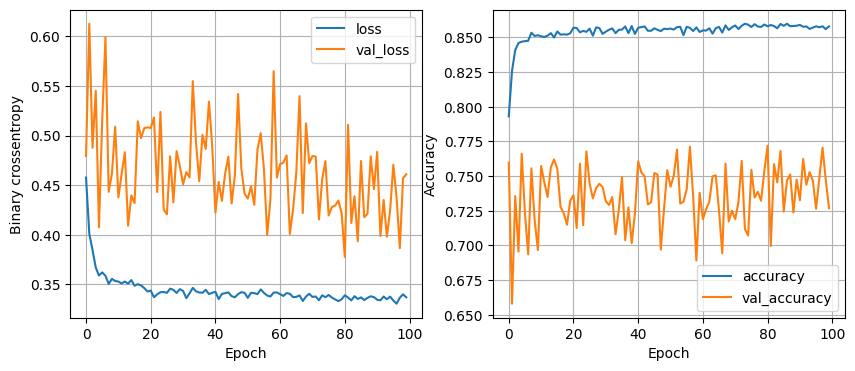

In [139]:
plot_history(history)

In [140]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):

  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

  nn_model.compile(optimizer = tf.keras.optimizers.Adam(lr),
                 loss = 'binary_crossentropy',
                 metrics=['accuracy'])

  history = nn_model.fit(
      x_train, y_train,
      epochs = epochs,
      batch_size = batch_size,
      validation_split=0.2,
      verbose = 0
  )

  return nn_model,history

16 nodes, dropout 0, lr0.01, batch size 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


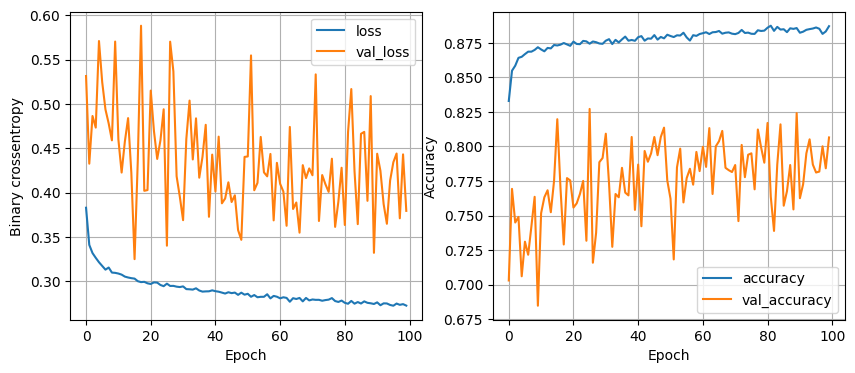

16 nodes, dropout 0, lr0.01, batch size 64


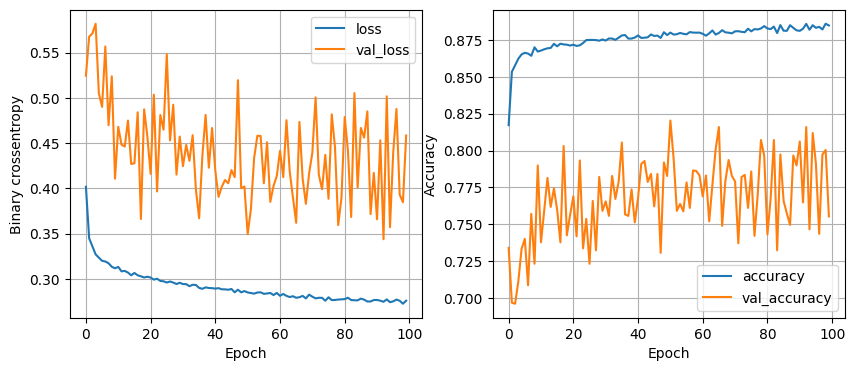

16 nodes, dropout 0, lr0.01, batch size 128


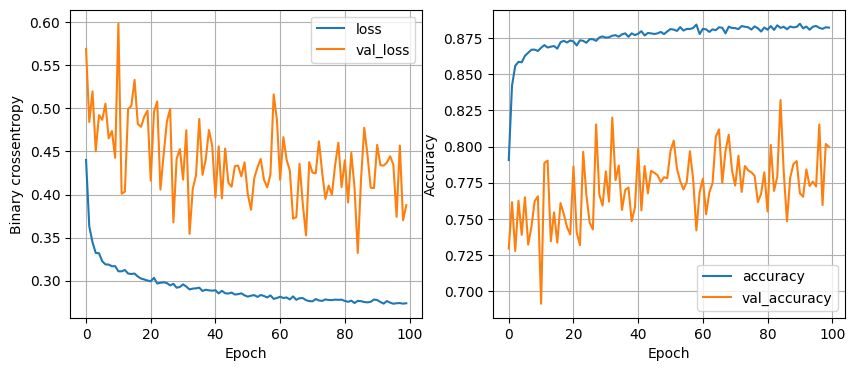

16 nodes, dropout 0, lr0.005, batch size 32


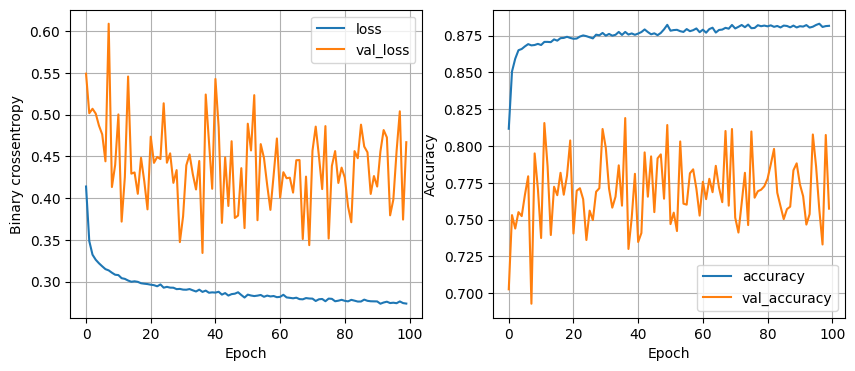

16 nodes, dropout 0, lr0.005, batch size 64


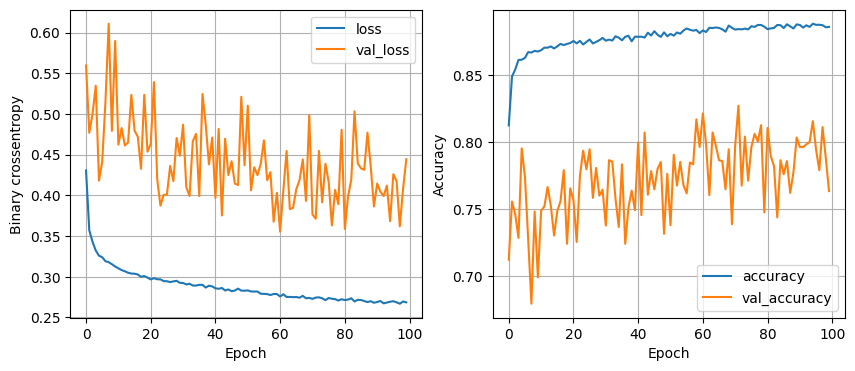

16 nodes, dropout 0, lr0.005, batch size 128


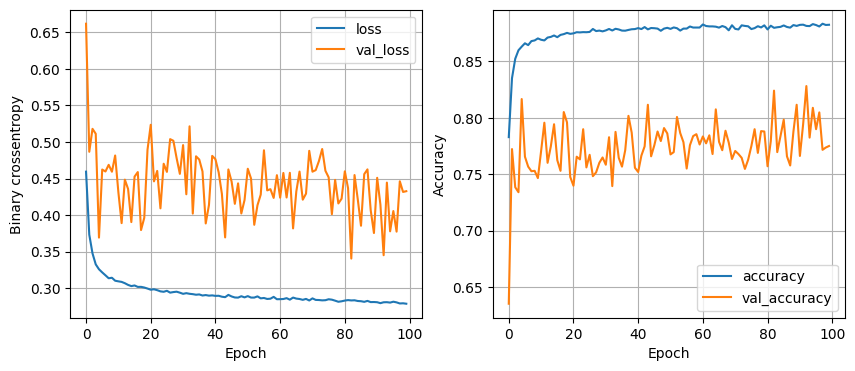

16 nodes, dropout 0, lr0.001, batch size 32


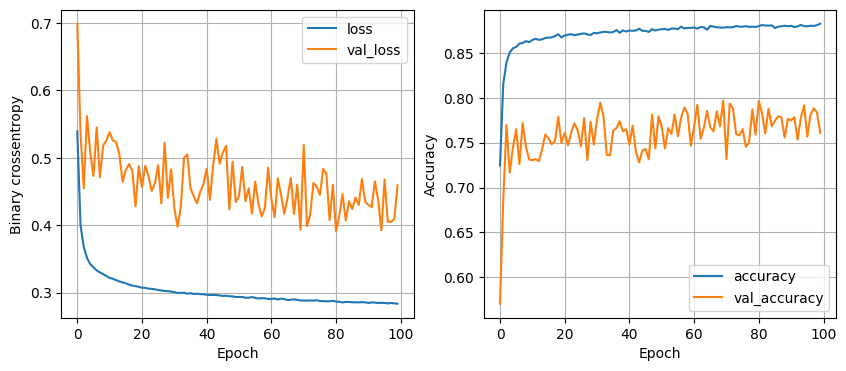

16 nodes, dropout 0, lr0.001, batch size 64


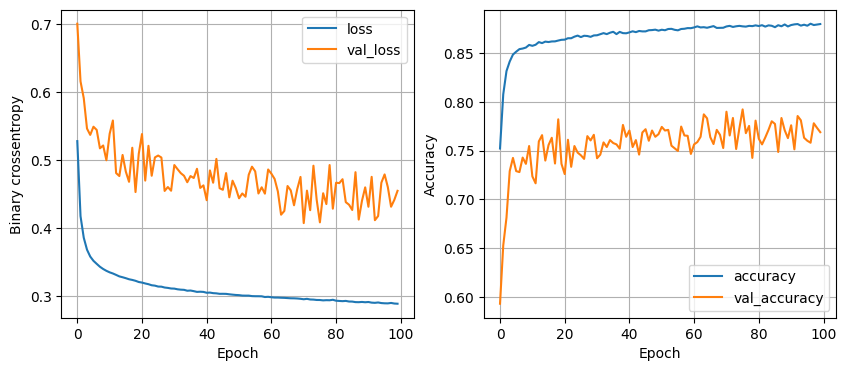

16 nodes, dropout 0, lr0.001, batch size 128


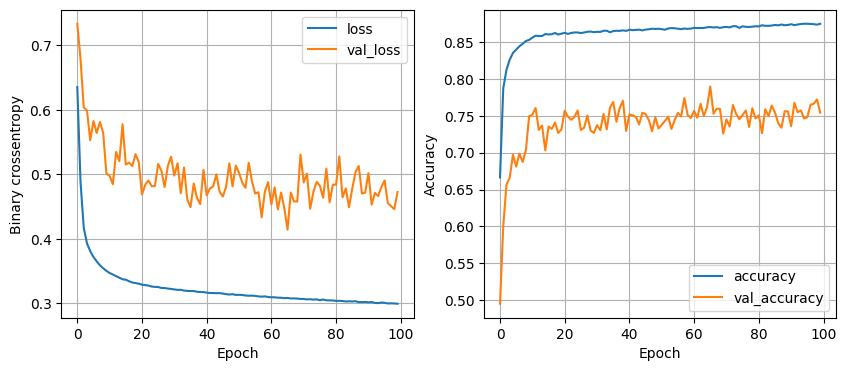

16 nodes, dropout 0.2, lr0.01, batch size 32


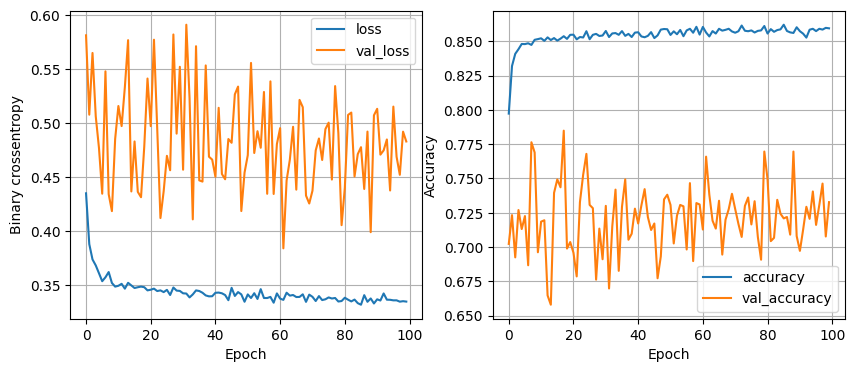

16 nodes, dropout 0.2, lr0.01, batch size 64


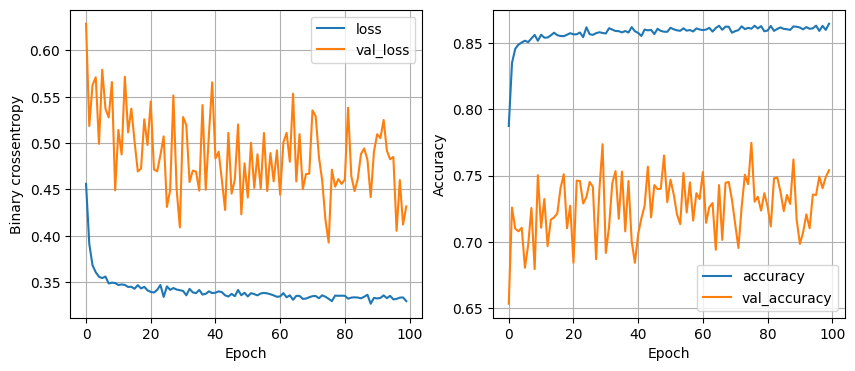

16 nodes, dropout 0.2, lr0.01, batch size 128


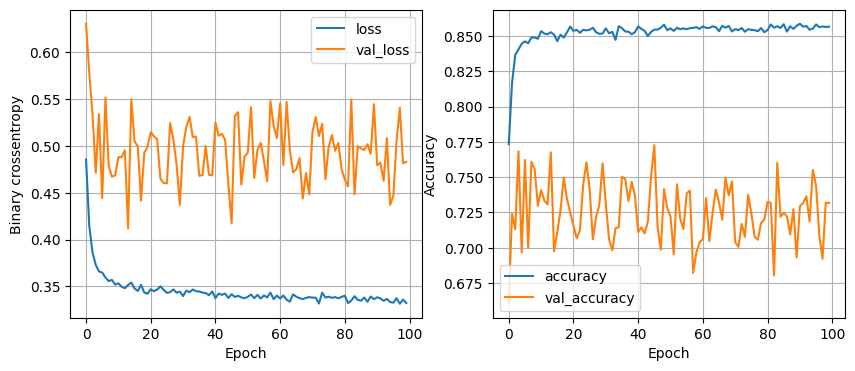

16 nodes, dropout 0.2, lr0.005, batch size 32


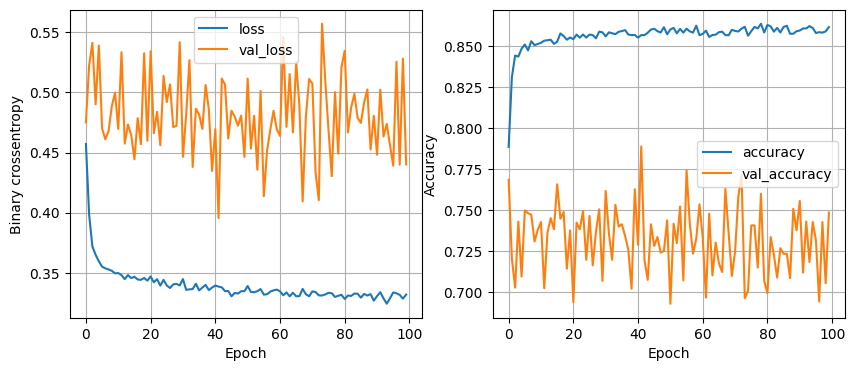

16 nodes, dropout 0.2, lr0.005, batch size 64


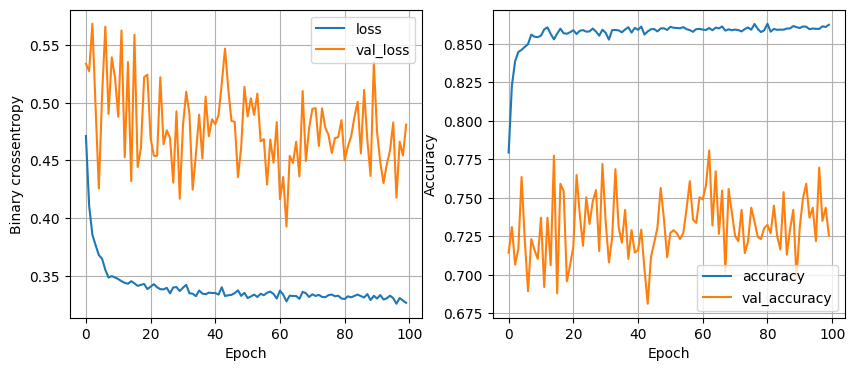

16 nodes, dropout 0.2, lr0.005, batch size 128


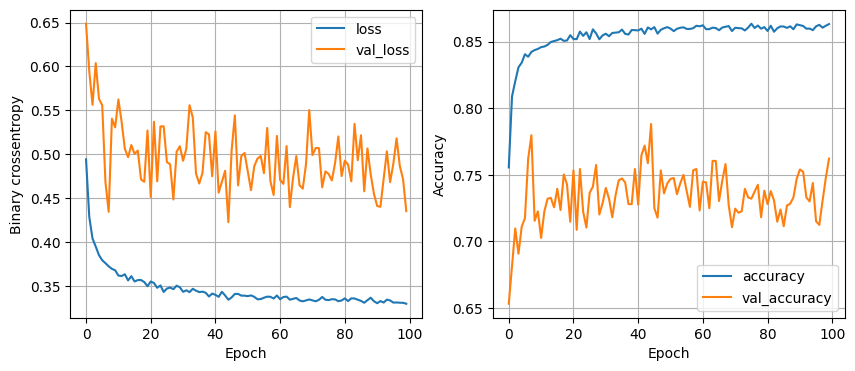

16 nodes, dropout 0.2, lr0.001, batch size 32


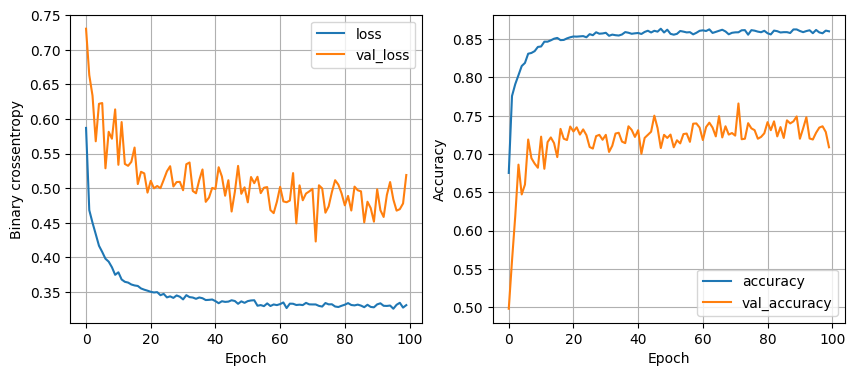

16 nodes, dropout 0.2, lr0.001, batch size 64


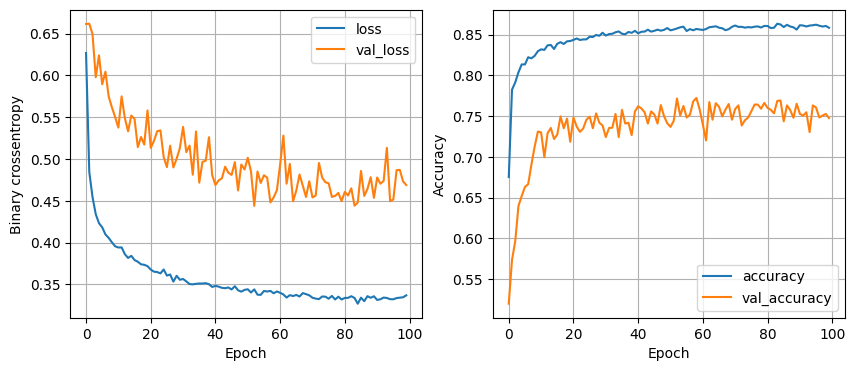

16 nodes, dropout 0.2, lr0.001, batch size 128


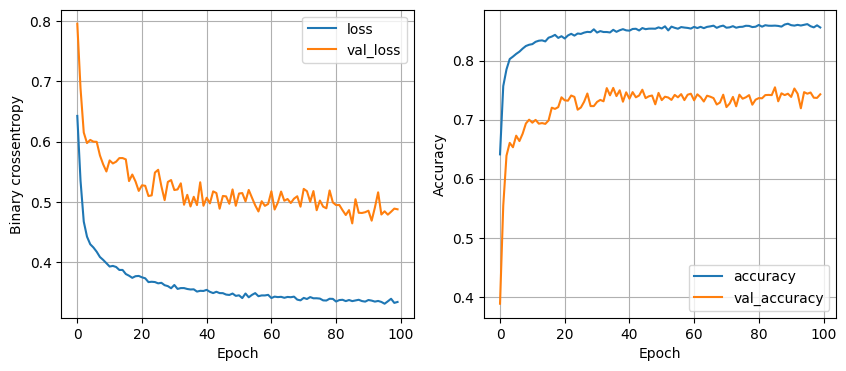

32 nodes, dropout 0, lr0.01, batch size 32


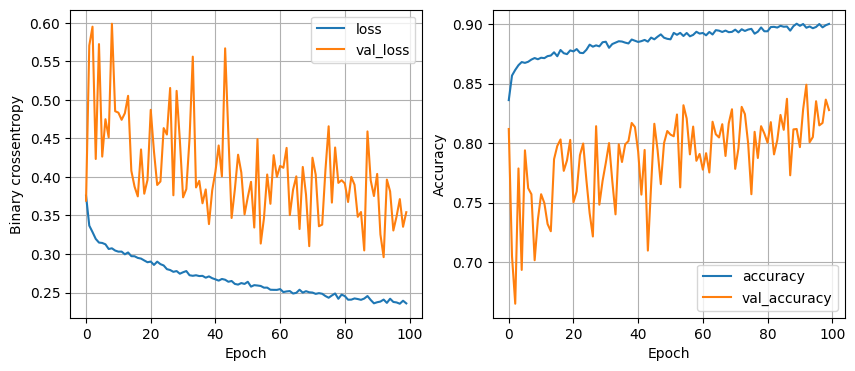

32 nodes, dropout 0, lr0.01, batch size 64


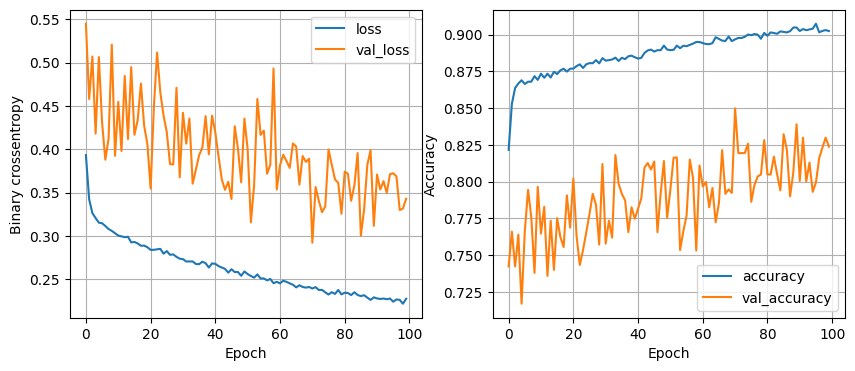

32 nodes, dropout 0, lr0.01, batch size 128


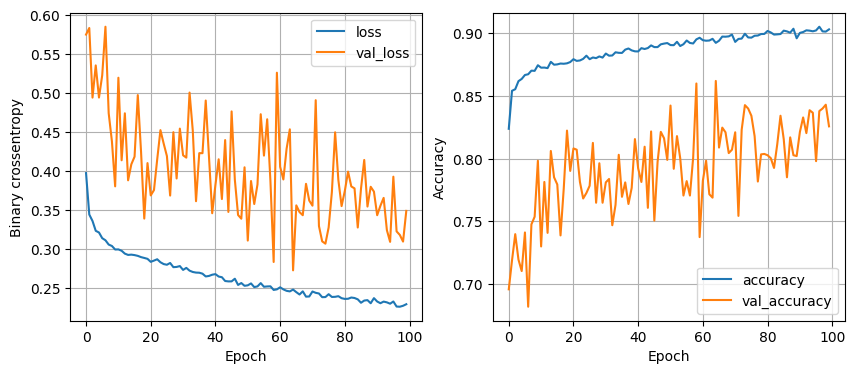

32 nodes, dropout 0, lr0.005, batch size 32


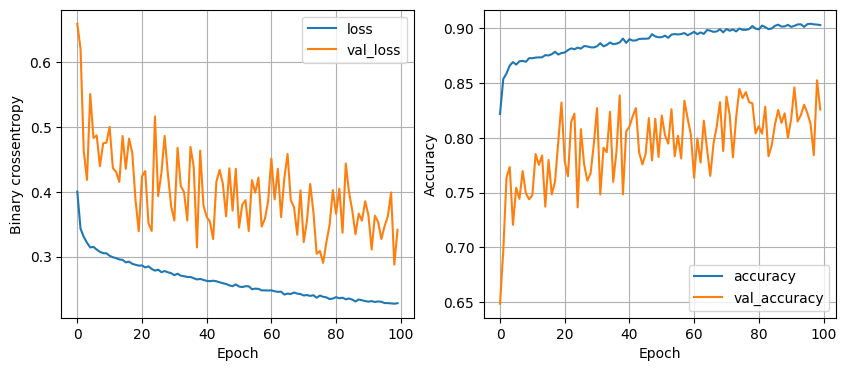

32 nodes, dropout 0, lr0.005, batch size 64


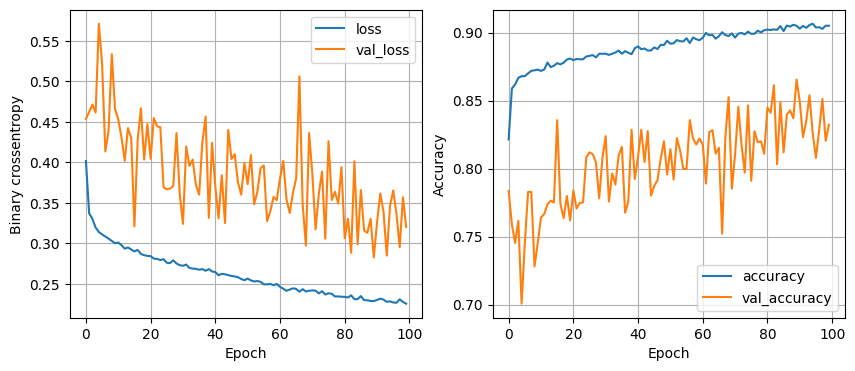

32 nodes, dropout 0, lr0.005, batch size 128


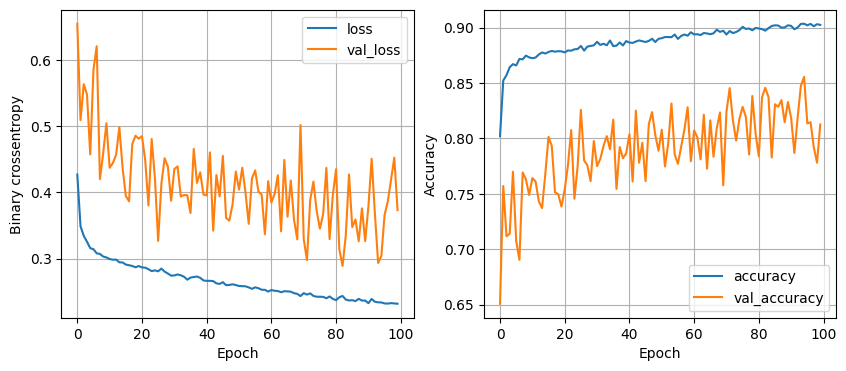

32 nodes, dropout 0, lr0.001, batch size 32


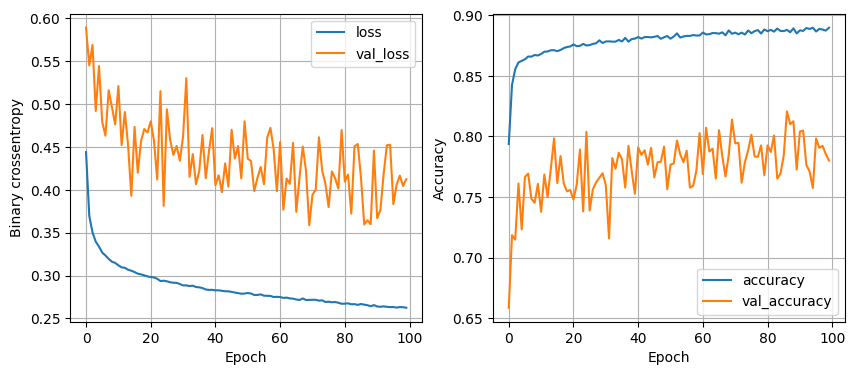

32 nodes, dropout 0, lr0.001, batch size 64


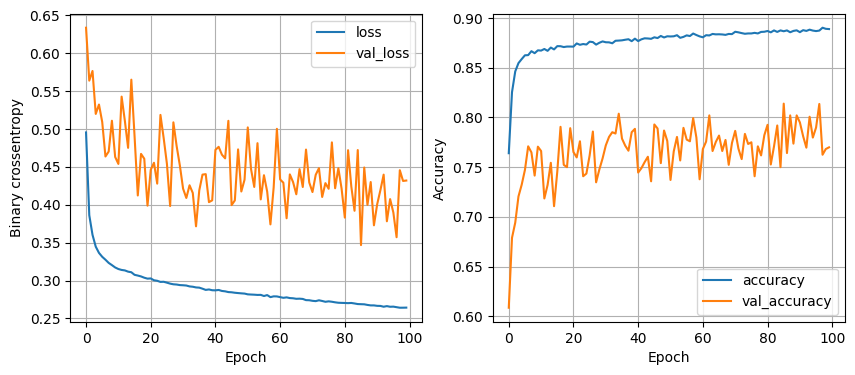

32 nodes, dropout 0, lr0.001, batch size 128


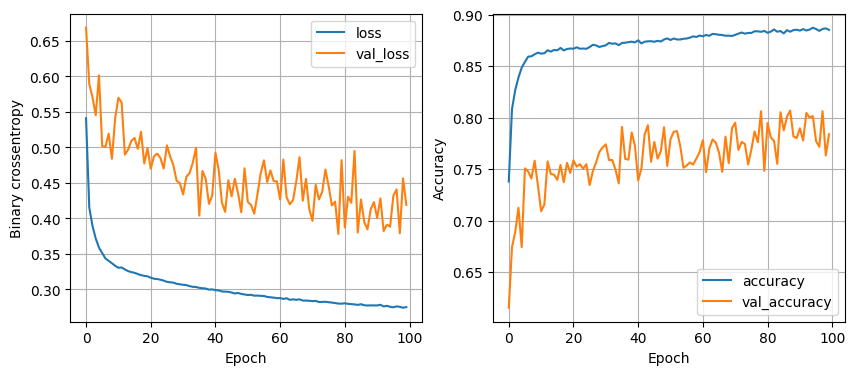

32 nodes, dropout 0.2, lr0.01, batch size 32


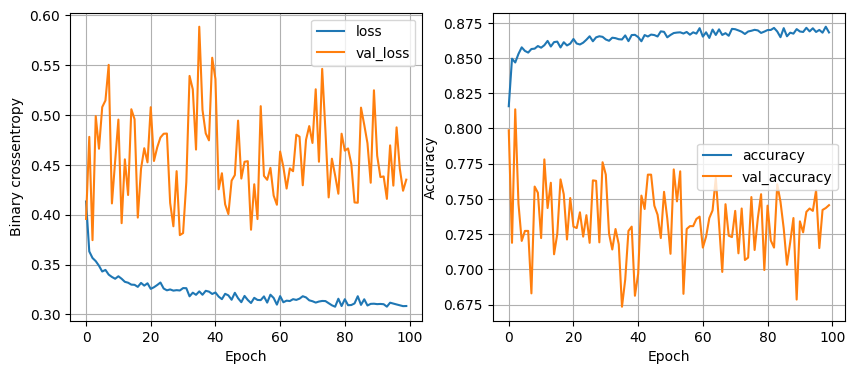

32 nodes, dropout 0.2, lr0.01, batch size 64


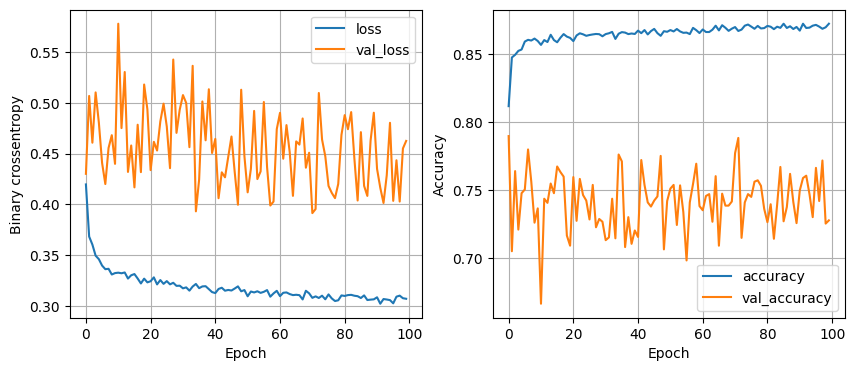

32 nodes, dropout 0.2, lr0.01, batch size 128


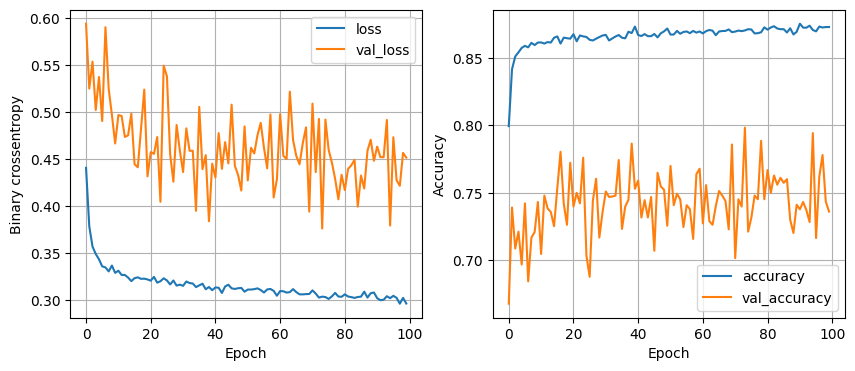

32 nodes, dropout 0.2, lr0.005, batch size 32


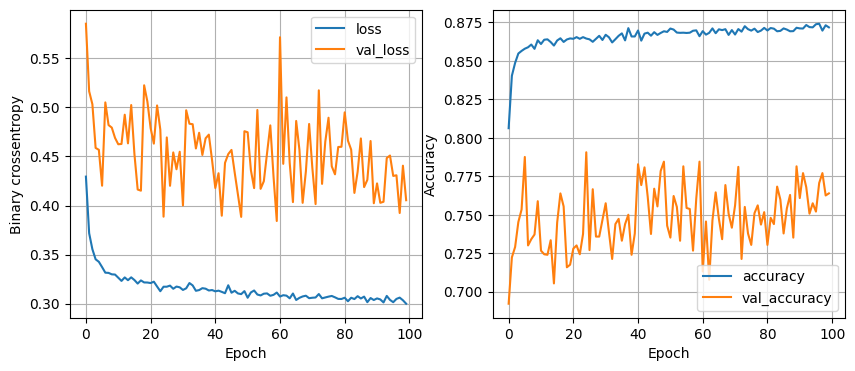

32 nodes, dropout 0.2, lr0.005, batch size 64


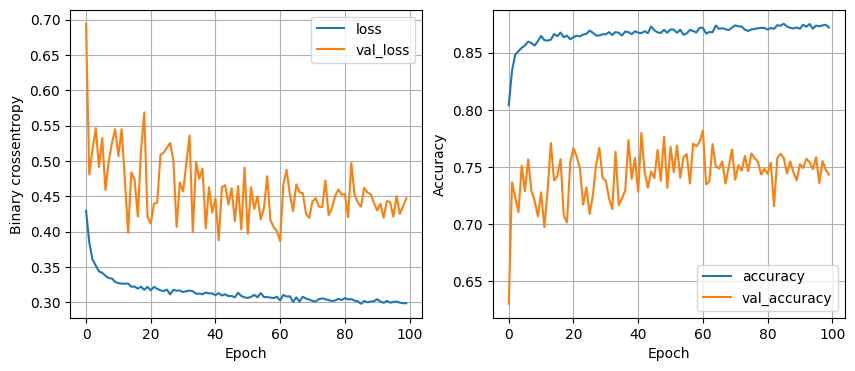

32 nodes, dropout 0.2, lr0.005, batch size 128


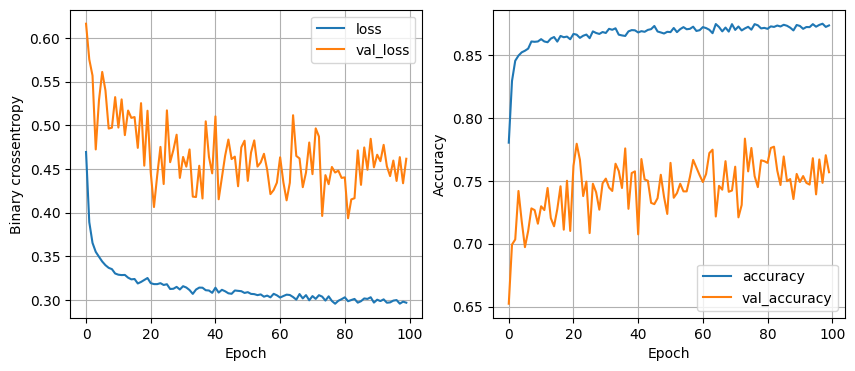

32 nodes, dropout 0.2, lr0.001, batch size 32


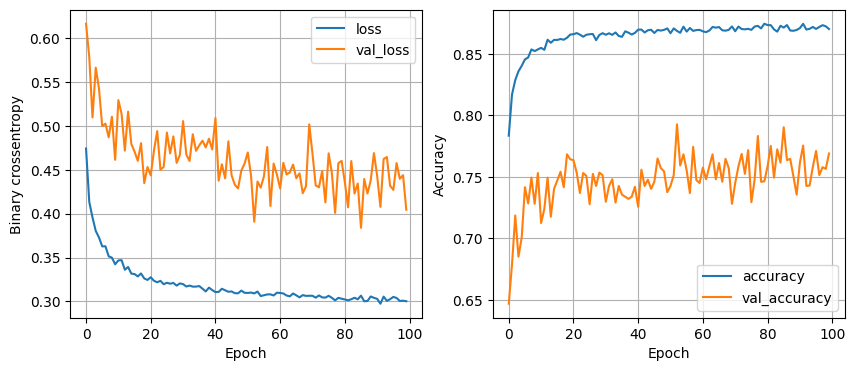

32 nodes, dropout 0.2, lr0.001, batch size 64


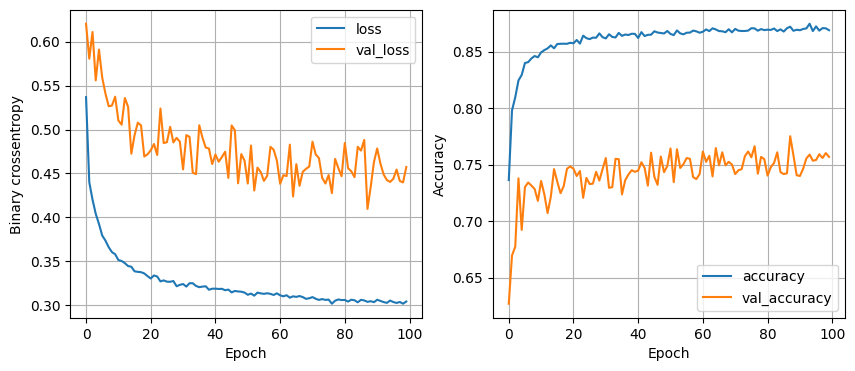

32 nodes, dropout 0.2, lr0.001, batch size 128


In [ ]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100 # Renamed from epoches for consistency with function parameter
for num_nodes in [16, 32]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"{num_nodes} nodes, dropout { dropout_prob}, lr{lr}, batch size {batch_size}")
        nn_model, history = train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)
        val_loss = nn_model.evaluate(x_valid, y_valid, verbose=0)[0] # Fixed 'model' to 'nn_model' and 'evalute' to 'evaluate'

        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = nn_model

In [ ]:
y_pred = least_loss_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)
print(classification_report(y_test, y_pred))